In [2]:
import os

os.getcwd()

'/disk/u/gio/handoff/notebooks'

In [6]:
import json

data = []
with open("../experiment_1_results.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

In [11]:
data[0].keys()

dict_keys(['problem', 'solution', 'full_cot', 'steps', 'total_steps', 'essp_index', 'step_accuracies'])

In [7]:
steps_1 = data[0]['steps']

In [15]:
len(steps_1)

847

In [13]:
step_accuracies_1 = data[0]['step_accuracies']
len(step_accuracies_1)

659

In [14]:
essp_index_1 = data[0]['essp_index']
essp_index_1

658

In [31]:
final_step_1 = steps_1[essp_index_1]

In [17]:
solution_1 = data[0]['solution']
solution_1

"There are $\\binom{6}{3}=20$ ways for Ryan to arrange the lamps, and $\\binom{6}{3}=20$ ways for him to choose which lamps are on, giving $20\\cdot20=400$ total possible outcomes. There are two cases for the desired outcomes: either the left lamp is on, or it isn't. If the left lamp is on, there are $\\binom{5}{2}=10$ ways to choose which other lamps are on, and $\\binom{5}{2}=10$ ways to choose which other lamps are red. This gives $10\\cdot10=100$ possibilities. If the first lamp isn't on, there are $\\binom{5}{3}=10$ ways to choose which lamps are on, and since both the leftmost lamp and the leftmost lit lamp must be red, there are $\\binom{4}{1}=4$ ways to choose which other lamp is red. This case gives 40 valid possibilities, for a total of 140 valid arrangements out of 400. Therefore, the probability is $\\dfrac{140}{400}=\\boxed{\\dfrac{7}{20}}$."

In [33]:
final_step_1

'Therefore, P(B | A) = P(first lamp on) * 1 + P(first lamp off) * (2/5) = (1/2)*1 + (1/2)*(2/5) = 1/2 + 1/5 = 7/10.'

In [34]:
import sys
from pathlib import Path

# Add the handoff directory to the Python path
handoff_dir = Path.cwd().parent
sys.path.insert(0, str(handoff_dir))

from scripts.exp_1_essp import MathVerifier

verifier = MathVerifier()
solution_1_answer = verifier.extract_answer(solution_1)

print(f"{solution_1_answer=}")

solution_1_answer='\\dfrac{7}{20}'


In [72]:
# Go through each jsonl and construct a nice table that shows the final_step sentence next to the actual solution.
import pandas as pd

df = pd.DataFrame(data)

df['answer'] = df['solution'].apply(verifier.extract_answer)
df['last_step'] = df.apply(lambda row: row['steps'][row['essp_index']], axis=1)
df['last_step_answer'] = df['last_step'].apply(verifier.extract_answer).fillna(value='NA')
df['is_correct'] = df.apply(lambda row: row['answer'].strip() in row['last_step'] or row['last_step_answer'] in row['last_step'], axis=1)

last_step_answer_df = df[['last_step', 'answer', 'is_correct']]

last_step_answer_df.head()

,last_step,answer,is_correct
0,"Therefore, P(B | A) = P(first lamp on) * 1 + P...",\dfrac{7}{20},False
1,"So m/n = 119/12, so m + n = 119 + 12 = 131.",131,True
2,**Final Answer**\nThe real numbers $ a $ are a...,"\left( -\infty, \frac{3}{4} \right)",True
3,Number of plots: 78*(3²)=78*9=702.,702,True
4,Since x and y can approach 10 and 2 respective...,8,True


In [73]:
# Style the dataframe for better readability
styled_df = last_step_answer_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'max-width': '400px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]},
    {'selector': 'td', 'props': [('vertical-align', 'top')]}
])

styled_df

,last_step,answer,is_correct
0,"Therefore, P(B | A) = P(first lamp on) * 1 + P(first lamp off) * (2/5) = (1/2)*1 + (1/2)*(2/5) = 1/2 + 1/5 = 7/10.",\dfrac{7}{20},False
1,"So m/n = 119/12, so m + n = 119 + 12 = 131.",131,True
2,"**Final Answer** The real numbers $ a $ are all those less than $ \frac{3}{4} $, so the solution is $\boxed{\left( -\infty, \dfrac{3}{4} \right)}$.","\left( -\infty, \frac{3}{4} \right)",True
3,Number of plots: 78*(3²)=78*9=702.,702,True
4,"Since x and y can approach 10 and 2 respectively, the maximum |x - y| approaches 10 - 2 = 8.",8,True
5,"Okay, so I need to compute this binary arithmetic problem: 1011₂ + 101₂ - 1100₂ + 1101₂.",10001_2,False
6,The number of divisors of 2n is (a+1 + 1)(b + 1)(...,35,False
7,"Let me compute this: For t=1: C(4,0)^3 = 1^3 = 1 t=2: C(4,1)^3 = 4^3 = 64 t=3: C(4,2)^3 = 6^3 = 216 t=4: C(4,3)^3 = 4^3 = 64 t=5: C(4,4)^3 = 1^3 = 1 Therefore, total N_total = 1 + 64 + 216 + 64 + 1 = 346.",346,True
8,"Therefore, the minimal |S_{2006}| is 3 * |T_{2006}| = 3 * 9 = 27.",27,True
9,"Since x ∈ [0,1), then -x ∈ (-1, 0].","(-1,0]",False


In [74]:
# Export with row numbers visible
last_step_answer_df.to_csv('corrections_needed.csv', index=True)
print("File saved! Open 'corrections_needed.csv' in Excel/Google Sheets")
print("Edit the 'is_correct' column, save, then run the cell below to reload")

File saved! Open 'corrections_needed.csv' in Excel/Google Sheets
Edit the 'is_correct' column, save, then run the cell below to reload


In [75]:
last_step_answer_df = pd.read_csv('corrections_needed.csv', index_col=0)
print(f"Reloaded {len(last_step_answer_df)} rows")
last_step_answer_df.head()

Reloaded 191 rows


,last_step,answer,is_correct
0,"Therefore, P(B | A) = P(first lamp on) * 1 + P...",\dfrac{7}{20},False
1,"So m/n = 119/12, so m + n = 119 + 12 = 131.",131,True
2,**Final Answer**\nThe real numbers $ a $ are a...,"\left( -\infty, \frac{3}{4} \right)",True
3,Number of plots: 78*(3²)=78*9=702.,702,True
4,Since x and y can approach 10 and 2 respective...,8,True


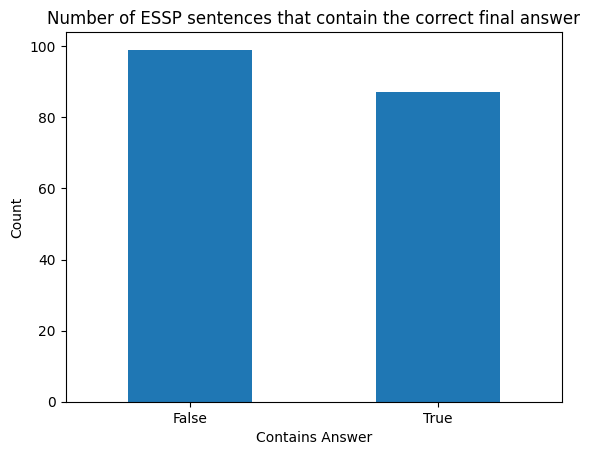

In [79]:
import matplotlib.pyplot as plt

# Simple bar chart of correct vs incorrect
last_step_answer_df['is_correct'].value_counts().plot(kind='bar')
plt.title('Number of ESSP sentences that contain the correct final answer')
plt.xlabel('Contains Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()